In [29]:
# Install Packages
%pip install yfinance
%pip install matplotlib.pyplot
%pip install pandas
%pip install rpy2
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [28]:
%load_ext rpy2.ipython

In [118]:
# Import Packages
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

The 11 Stock Market Sectors
1. Communication Services
2. Consumer Discretionary
3. Consumer Staples
4. Energy
5. Financials
6. Health Care
7. Industries
8. Information Technology
9. Materials
10. Real Estate
11. Utilities

In [3]:
tickers = ['MRNA', 'AAPL']

df = yf.download(
    tickers= tickers,
    start= '2020-01-01',
    end = '2026-01-01',
    interval = '1d'

)

df.head(5)

[*********************100%***********************]  2 of 2 completed


Price           Close                  High                   Low             \
Ticker           AAPL       MRNA       AAPL       MRNA       AAPL       MRNA   
Date                                                                           
2020-01-02  72.271538  19.230000  72.331694  19.809999  71.029915  18.879999   
2020-01-03  71.568932  18.889999  72.326897  19.360001  71.345153  18.719999   
2020-01-06  72.139214  18.129999  72.177714  18.740000  70.442814  18.010000   
2020-01-07  71.799904  17.780001  72.403866  18.320000  71.580935  17.680000   
2020-01-08  72.954918  17.980000  73.255698  18.080000  71.503953  17.760000   

Price            Open                Volume           
Ticker           AAPL       MRNA       AAPL     MRNA  
Date                                                  
2020-01-02  71.282568  19.570000  135480400  1233600  
2020-01-03  71.501557  19.020000  146322800  1751000  
2020-01-06  70.693065  18.700001  118387200  1606500  
2020-01-07  72.148805  18.150000  108872000  1461400  
2020-01-08  71.503953  17.990000  132079200  1041600

In [4]:
# Pre-Process Data
df = df.stack(level="Ticker").reset_index()

In [5]:
df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']]

In [6]:
df.columns.name = None

In [7]:
df = df.set_index("Date")

In [8]:
df

,Open,High,Low,Close,Volume,Ticker
Date,,,,,,
2020-01-02,71.282568,72.331694,71.029915,72.271538,135480400,AAPL
2020-01-02,19.570000,19.809999,18.879999,19.230000,1233600,MRNA
2020-01-03,71.501557,72.326897,71.345153,71.568932,146322800,AAPL
2020-01-03,19.020000,19.360001,18.719999,18.889999,1751000,MRNA
2020-01-06,70.693065,72.177714,70.442814,72.139214,118387200,AAPL
...,...,...,...,...,...,...
2025-12-29,31.000000,31.235001,30.650000,31.150000,5924400,MRNA
2025-12-30,272.069428,273.335969,271.540868,272.338684,22139600,AAPL
2025-12-30,31.129999,31.250000,30.365000,30.410000,5666800,MRNA


In [9]:
mrna = df.loc[df['Ticker'] == "MRNA"]

In [10]:
mrna_close = mrna['Close']

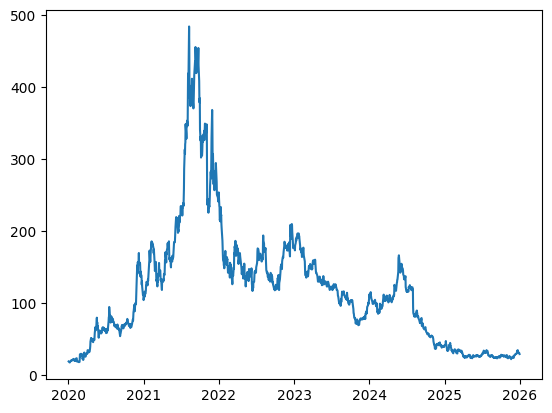

In [11]:
plt.plot(mrna_close.index, mrna_close.values)

In [12]:
aapl = df.loc[df["Ticker"] == "AAPL"]

In [13]:
aapl_close = aapl['Close']

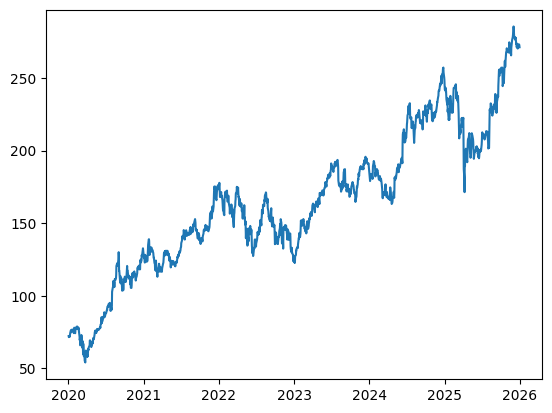

In [14]:
plt.plot(aapl_close.index, aapl_close.values)

In [15]:
aapl_close.corr(mrna_close, method="spearman")

np.float64(-0.3260839048160225)

In [35]:
tickers = ['SPY', 'GLD']
df1 = yf.download(
    tickers=tickers,
    start="2019-01-01",
    end="2026-01-01",
    interval="1d"
)

[*********************100%***********************]  2 of 2 completed


In [36]:
df1 = df1.stack(level='Ticker', future_stack=True)
df1 = df1.reset_index()

df1.columns = df1.columns.str.lower()

In [37]:
df1 = df1[['date', 'open', 'high', 'low', 'close', 'volume', 'ticker']]

In [38]:
df1.set_index('date')

Price,open,high,low,close,volume,ticker
date,,,,,,
2019-01-02,121.349998,121.750000,120.879997,121.330002,12776200,GLD
2019-01-02,220.048707,224.727368,220.021870,223.805939,126925200,SPY
2019-01-03,121.779999,122.459999,121.730003,122.430000,15440800,GLD
2019-01-03,222.061533,222.365700,217.982251,218.465332,144140700,SPY
2019-01-04,121.320000,121.599998,120.690002,121.440002,13334000,GLD
...,...,...,...,...,...,...
2025-12-29,683.905508,685.556767,682.443308,684.213867,62559500,SPY
2025-12-30,403.600006,403.799988,398.559998,398.890015,10179000,GLD
2025-12-30,683.815972,684.920090,682.950576,683.378296,47160700,SPY


In [39]:
spy = df1.loc[df1['ticker'] == "SPY"]

In [ ]:
spy = spy.set_index("date")

KeyError: "None of ['date'] are in the columns"

In [54]:
spy['ret'] = spy['close'].pct_change()

In [55]:
spy['log_ret'] = np.log(spy['close'] / spy['close'].shift(1))

In [61]:
spy['cum_log_ret'] = spy['log_ret'].cumsum()

In [66]:
spy['100_cum_log_ret'] = spy['cum_log_ret'] + 100

<Axes: xlabel='date'>

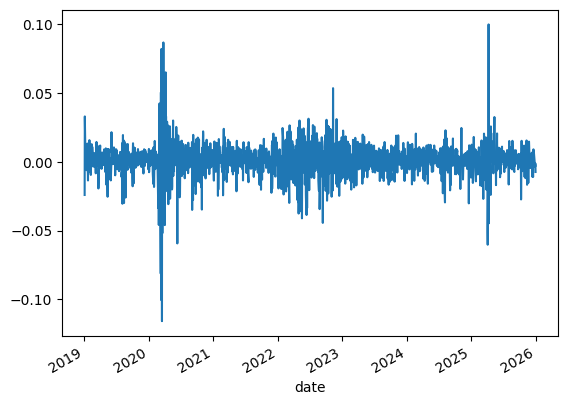

In [80]:
spy['log_ret'].plot()

In [83]:
gold = df1.loc[df1['ticker'] == "GLD"]

In [94]:
gold = gold.set_index('date')

In [95]:
gold['ret'] = gold['close'].pct_change()

In [96]:
gold['log_ret'] = np.log(gold['close'] / gold['close'].shift(1))

In [89]:
## Correlation Between Gold and the Stock Market
spy_log_ret = spy['log_ret']

In [91]:
spy_log_ret.dropna()

date
2019-01-03   -0.024152
2019-01-04    0.032947
2019-01-07    0.007854
2019-01-08    0.009351
2019-01-09    0.004663
                ...   
2025-12-24    0.003512
2025-12-26   -0.000101
2025-12-29   -0.003570
2025-12-30   -0.001222
2025-12-31   -0.007436
Name: log_ret, Length: 1759, dtype: float64

In [97]:
gld_log_ret = gold['log_ret']

In [98]:
gld_log_ret.dropna()

date
2019-01-03    0.009025
2019-01-04   -0.008119
2019-01-07    0.003453
2019-01-08   -0.002712
2019-01-09    0.006398
                ...   
2025-12-24   -0.004143
2025-12-26    0.011609
2025-12-29   -0.044504
2025-12-30    0.000727
2025-12-31   -0.006489
Name: log_ret, Length: 1759, dtype: float64

In [99]:
spy_log_ret.corr(gld_log_ret, method="spearman")

np.float64(0.06980444746102141)

Suspected Structure Breaks within the market:

1. 2020-01-22
2. 2021-02-05
3. 2022-02-22
4. 2023-03-01

This information was found using a Bai-Perron test within R Studio

Hypothesis: Diversification will fail in a market crash.
Three Types of risk:
1. Industry Risk (Diversified away by investing in different sectors)
2. Idiosyncratic Risk
3. Market Risk (Market risk cannot be diversified away by uncorrelated equities)

To test this hypothesis I will be using five stocks from different sectors:
1. Nividia
2. Walmart
3. Costco
4. NextEra Energy
5. AbbVie Common Stock 

The SPY will be used as a proxy to the market.


In [ ]:
tickers = ['NVDA', 'WMT', 'COST', 'NEE', 'ABBV']

df2 = yf.download(
    tickers=tickers,
    start = '2019-01-01',
    end = '2026-01-01',
    interval='1d'
)


[*********************100%***********************]  5 of 5 completed


In [102]:
df2 = df2.stack(level='Ticker', future_stack=True)
df2 = df2.reset_index()

df2.columns = df2.columns.str.lower()

In [105]:
df2

Price,date,ticker,close,high,low,open,volume
0,2019-01-02,ABBV,64.331520,65.795074,63.747536,65.780652,6908400
1,2019-01-02,COST,184.568375,184.874857,180.142566,180.728463,2143100
2,2019-01-02,NEE,34.979034,35.693733,34.810142,35.566033,10549600
3,2019-01-02,NVDA,3.373052,3.429013,3.220271,3.234881,508752000
4,2019-01-02,WMT,27.847113,27.939599,27.339935,27.339935,24458100
...,...,...,...,...,...,...,...
8795,2025-12-31,ABBV,223.212524,224.931868,223.153898,224.433653,3196900
8796,2025-12-31,COST,858.550781,864.185884,857.555175,860.780929,1490000
8797,2025-12-31,NEE,78.565720,78.966968,78.497215,78.966968,5036200
8798,2025-12-31,NVDA,186.272812,190.327864,186.262830,189.339079,120100500


In [106]:
df2 = df2.set_index('date')

In [ ]:
df2 = df2[['open', 'high', 'low', 'close', 'volume', 'ticker']]d

In [ ]:
# Create five dataframes for the five different tickers

nvidia = df2.loc[df2['ticker'] == "NVDA"]
walmart = df2.loc[df2['ticker'] == "WMT"]
costco = df2.loc[df2['ticker'] == "COST"]
nextera = df2.loc[df2['ticker'] == "NEE"]
AbbVie = df2.loc[df2['ticker'] == "ABBV"]

In [111]:
nvidia['ret'] = nvidia['close'].pct_change()

In [112]:
nvidia['log_ret'] = np.log(nvidia['close'] / nvidia['close'].shift(1))

In [114]:
nvidia.dropna()

Price,open,high,low,close,volume,ticker,ret,log_ret
date,,,,,,,,
2019-01-03,3.312880,3.346804,3.161833,3.169262,705552000,NVDA,-0.060417,-0.062319
2019-01-04,3.242310,3.410443,3.211606,3.372310,585620000,NVDA,0.064068,0.062099
2019-01-07,3.429509,3.587737,3.378252,3.550842,709160000,NVDA,0.052941,0.051587
2019-01-08,3.632308,3.634537,3.389890,3.462442,786016000,NVDA,-0.024895,-0.025211
2019-01-09,3.513699,3.577832,3.463185,3.530537,617260000,NVDA,0.019667,0.019476
...,...,...,...,...,...,...,...,...
2025-12-24,187.711052,188.679871,186.362690,188.380234,65528500,NVDA,-0.003171,-0.003176
2025-12-26,189.688640,192.455270,187.770981,190.297897,139740300,NVDA,0.010180,0.010128
2025-12-29,187.481334,188.530043,185.683524,187.990707,120006100,NVDA,-0.012124,-0.012198


In [115]:
walmart['ret'] = walmart['close'].pct_change()
walmart['log_ret'] = np.log(walmart['close'] / walmart['close'].shift(1))
costco['ret'] = costco['close'].pct_change()
costco['log_ret'] = np.log(costco['close'] / costco['close'].shift(1))
nextera['ret'] = nextera['close'].pct_change()
nextera['log_ret'] = np.log(nextera['close'] / nextera['close'].shift(1))
AbbVie['ret'] = AbbVie['close'].pct_change()
AbbVie['log_ret'] = np.log(AbbVie['close'] / AbbVie['close'].shift(1))

In [116]:
walmart.dropna()
costco.dropna()
nextera.dropna()
AbbVie.dropna()

Price,open,high,low,close,volume,ticker,ret,log_ret
date,,,,,,,,
2019-01-03,63.906157,64.021514,62.060493,62.211895,7653200,ABBV,-0.032948,-0.033503
2019-01-04,63.264538,64.266677,62.197510,64.216209,8910600,ABBV,0.032218,0.031709
2019-01-07,64.937144,65.434610,64.309904,65.153435,7281500,ABBV,0.014595,0.014489
2019-01-08,65.751830,66.544894,65.175063,65.456238,7478300,ABBV,0.004648,0.004637
2019-01-09,65.521103,65.888795,63.055411,63.307747,9971900,ABBV,-0.032823,-0.033374
...,...,...,...,...,...,...,...,...
2025-12-24,224.160124,225.469170,223.691200,224.580185,1744900,ABBV,0.004808,0.004796
2025-12-26,224.511813,225.283560,223.398129,224.668106,1593900,ABBV,0.000391,0.000391
2025-12-29,224.834174,226.660993,224.433656,225.508240,3803000,ABBV,0.003739,0.003732


In [160]:
# grab each log_ret column, name it by ticker, align on the date index
combined = pd.concat(
    [nvidia['log_ret'].rename('NVDA'),
     walmart['log_ret'].rename('WMT'),
     costco['log_ret'].rename('COST'),
     nextera['log_ret'].rename('NEE'),
     AbbVie['log_ret'].rename('ABBV'),
     spy['log_ret'].rename('spy')],
    axis=1
).dropna()

print(f"Aligned observations: {len(combined)}")   # sanity check — expect ~1759

corr = combined.corr()          # Pearson log-return correlation matrix

Aligned observations: 1759


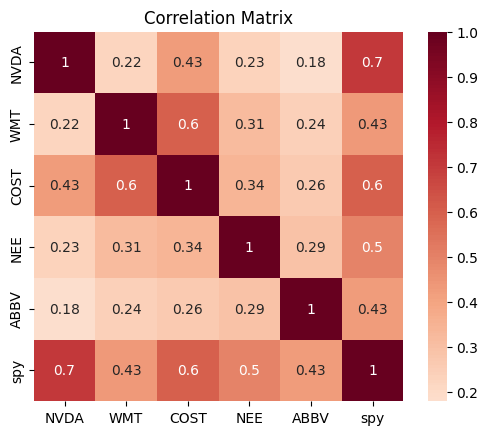

In [161]:
## Correlation Matrix Chart
sns.heatmap(
    corr,
    annot=True,
    cmap = 'RdBu_r',
    center=0,
    square=True
)
plt.title('Correlation Matrix')
plt.tight_layout
plt.show()

In [128]:
nvidia['cumsum_log_ret'] = nvidia['log_ret'].cumsum()+100
walmart['cumsum_log_ret'] = walmart['log_ret'].cumsum()+100
costco['cumsum_log_ret'] = costco['log_ret'].cumsum()+100
nextera['cumsum_log_ret'] = nextera['log_ret'].cumsum()+100
AbbVie['cumsum_log_ret'] = AbbVie['log_ret'].cumsum()+100

In [129]:
nvidia.dropna()
walmart.dropna()
costco.dropna()
nextera.dropna()
AbbVie.dropna()

Price,open,high,low,close,volume,ticker,ret,log_ret,cumsum_log_ret
date,,,,,,,,,
2019-01-03,63.906157,64.021514,62.060493,62.211895,7653200,ABBV,-0.032948,-0.033503,99.966497
2019-01-04,63.264538,64.266677,62.197510,64.216209,8910600,ABBV,0.032218,0.031709,99.998206
2019-01-07,64.937144,65.434610,64.309904,65.153435,7281500,ABBV,0.014595,0.014489,100.012695
2019-01-08,65.751830,66.544894,65.175063,65.456238,7478300,ABBV,0.004648,0.004637,100.017332
2019-01-09,65.521103,65.888795,63.055411,63.307747,9971900,ABBV,-0.032823,-0.033374,99.983958
...,...,...,...,...,...,...,...,...,...
2025-12-24,224.160124,225.469170,223.691200,224.580185,1744900,ABBV,0.004808,0.004796,101.250183
2025-12-26,224.511813,225.283560,223.398129,224.668106,1593900,ABBV,0.000391,0.000391,101.250575
2025-12-29,224.834174,226.660993,224.433656,225.508240,3803000,ABBV,0.003739,0.003732,101.254307


In [130]:
spy.dropna()

Price,open,high,low,close,volume,ticker,ret,log_ret,cum_log_ret,100_cum_log_ret
date,,,,,,,,,,
2019-01-03,222.061533,222.365700,217.982251,218.465332,144140700,SPY,-0.023863,-0.024152,-0.024152,99.975848
2019-01-04,221.489004,226.427088,221.113282,225.782990,142628800,SPY,0.033496,0.032947,0.008795,100.008795
2019-01-07,226.051345,228.967670,225.156765,227.563187,103139100,SPY,0.007885,0.007854,0.016649,100.016649
2019-01-08,229.745948,230.184283,227.223227,229.701202,102512600,SPY,0.009395,0.009351,0.026000,100.026000
2019-01-09,230.407954,231.615642,229.182384,230.774734,95006600,SPY,0.004674,0.004663,0.030663,100.030663
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,684.313382,687.178163,684.164151,686.730530,39445600,SPY,0.003518,0.003512,1.121163,101.121163
2025-12-26,686.989161,688.003728,685.626408,686.660889,41613300,SPY,-0.000101,-0.000101,1.121061,101.121061
2025-12-29,683.905508,685.556767,682.443308,684.213867,62559500,SPY,-0.003564,-0.003570,1.117491,101.117491


1. 2020-01-22
2. 2021-02-05
3. 2022-02-22
4. 2023-03-01

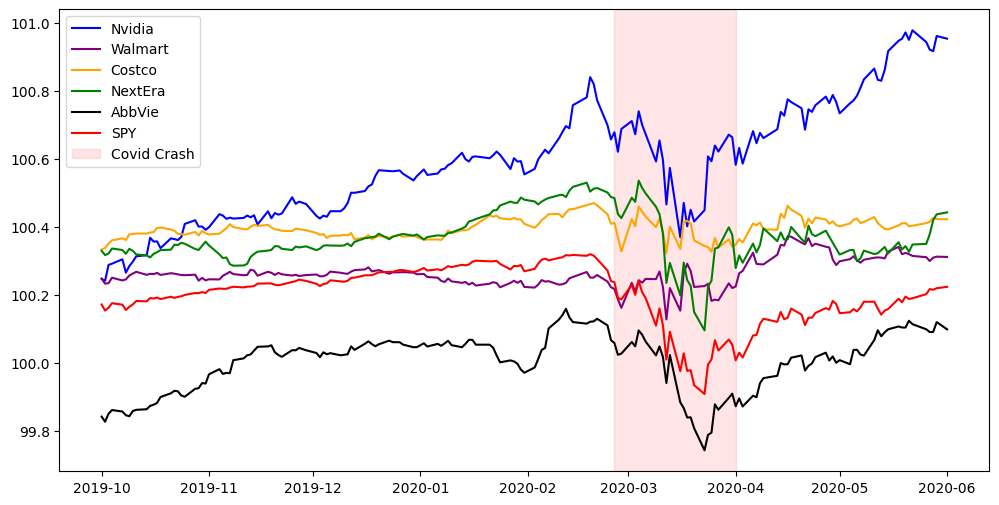

In [ ]:
# Log Returns

start, end = '2019-10-01', '2020-06-01'


plt.figure(figsize=(12,6))
plt.plot(nvidia.loc[start:end, 'cumsum_log_ret'],  label="Nvidia",  color="blue")
plt.plot(walmart.loc[start:end, 'cumsum_log_ret'], label="Walmart", color="purple")
plt.plot(costco.loc[start:end, 'cumsum_log_ret'],  label="Costco",  color="orange")
plt.plot(nextera.loc[start:end, 'cumsum_log_ret'], label="NextEra", color="green")
plt.plot(AbbVie.loc[start:end, 'cumsum_log_ret'],  label="AbbVie",  color="black")
plt.plot(spy.loc[start:end, '100_cum_log_ret'],    label="SPY",     color="red")
plt.axvspan(pd.Timestamp('2020-02-26'), pd.Timestamp('2020-04-01'), color="red", alpha=0.1, label = "Covid Crash")
plt.legend(); plt.show()


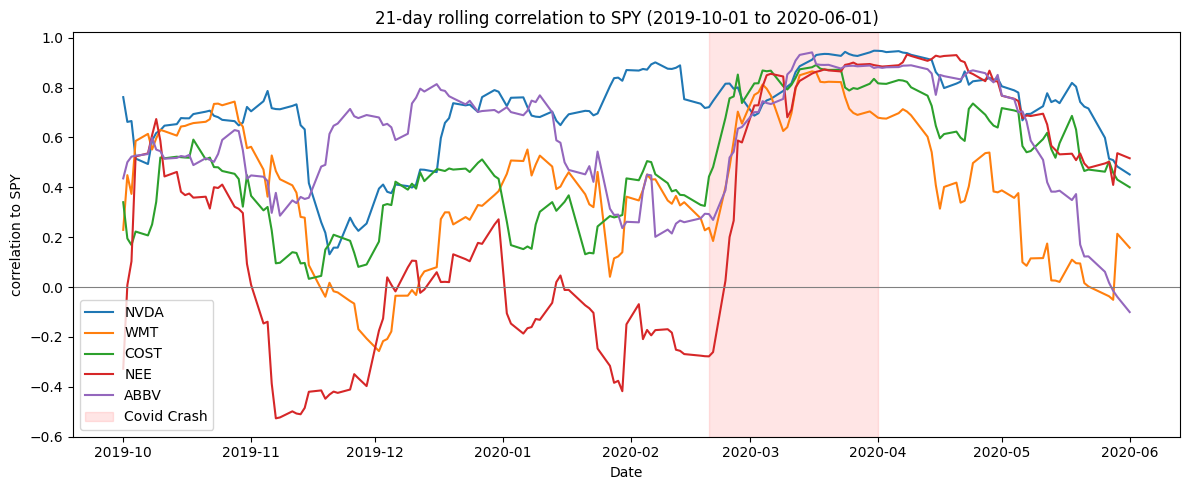

In [145]:
import matplotlib.pyplot as plt

pair = pd.concat([
    spy['log_ret'].rename('SPY'),
    nvidia['log_ret'].rename('NVDA'),
    walmart['log_ret'].rename('WMT'),
    costco['log_ret'].rename('COST'),
    nextera['log_ret'].rename('NEE'),
    AbbVie['log_ret'].rename('ABBV'),
], axis=1).dropna()

window = 21
stocks = ['NVDA', 'WMT', 'COST', 'NEE', 'ABBV']
start, end = '2019-10-01', '2020-06-01'

plt.figure(figsize=(12, 5))
for s in stocks:
    roll = pair[s].rolling(window).corr(pair['SPY'])
    plt.plot(roll.loc[start:end].index, roll.loc[start:end], label=s)

plt.axhline(0, color='grey', lw=0.8)
plt.title(f'{window}-day rolling correlation to SPY ({start} to {end})')
plt.axvspan(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-01'), color="red", alpha=0.1, label = "Covid Crash")
plt.ylabel('correlation to SPY')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

In [146]:
nvidia

Price,open,high,low,close,volume,ticker,ret,log_ret,cumsum_log_ret
date,,,,,,,,,
2019-01-02,3.234881,3.429013,3.220271,3.373052,508752000,NVDA,NaN,NaN,NaN
2019-01-03,3.312880,3.346804,3.161833,3.169262,705552000,NVDA,-0.060417,-0.062319,99.937681
2019-01-04,3.242310,3.410443,3.211606,3.372310,585620000,NVDA,0.064068,0.062099,99.999780
2019-01-07,3.429509,3.587737,3.378252,3.550842,709160000,NVDA,0.052941,0.051587,100.051367
2019-01-08,3.632308,3.634537,3.389890,3.462442,786016000,NVDA,-0.024895,-0.025211,100.026156
...,...,...,...,...,...,...,...,...,...
2025-12-24,187.711052,188.679871,186.362690,188.380234,65528500,NVDA,-0.003171,-0.003176,104.022645
2025-12-26,189.688640,192.455270,187.770981,190.297897,139740300,NVDA,0.010180,0.010128,104.032773
2025-12-29,187.481334,188.530043,185.683524,187.990707,120006100,NVDA,-0.012124,-0.012198,104.020575


In [ ]:
# Returns pre_crash, during, and post_crash
pre_crash = ('2019-10-01', '2020-02-19')
pre_total = nvidia.loc[pre_crash[0]:pre_crash[1], 'log_ret'].sum()
pre_simple_pct = (np.exp(pre_total) - 1) * 100
print(pre_simple_pct)

crash = ('2020-02-20', '2020-04-01')
start, end = crash
crash_total = nvidia.loc[start:end, 'log_ret'].sum()
crash_simple_pct = (np.exp(crash_total) - 1) * 100
print(crash_simple_pct)

post_crash = ('2020-04-02', '2020-06-01')
start, end = post_crash
post_crash_total = nvidia.loc[start:end, 'log_ret'].sum()
post_crash_simple_pct = (np.exp(post_crash_total) - 1) * 100
print(post_crash_simple_pct)

# The three Open Prices for three states

pre_crash_open = ('2020-01-06')
pre_open = nvidia.loc[pre_crash_open, 'open']
print(f"Trading Price Before Crash {pre_open}")

crash_open_p = ('2020-03-16')
crash_open = nvidia.loc[crash_open_p, 'open']
print(f"Trading Price During Crash {crash_open}")

post_crash_open = ('2020-04-14')
post_open = nvidia.loc[post_crash_open, 'open']
print(f"Trading Price Post Crash {post_open}")



80.92264615778217
-22.71515767108251
44.917084657076956
Trading Price Before Crash 5.77512766888247
Trading Price During Crash 5.283352557854332
Trading Price Post Crash 6.840177873439645


In [165]:
# Correlation pre_crash, during, post_crash
start, end = ('2019-10-01', '2020-02-19')
pre_corr = walmart.loc[start:end, 'log_ret'].corr(spy.loc[start:end, 'log_ret'])
print(f"Pre Crash Correlation {pre_corr:.3f}")

start, end = ('2020-03-01', '2020-04-01')
during_corr = walmart.loc[start:end, 'log_ret'].corr(spy.loc[start:end, 'log_ret'])
print(f"During Crash Correlation {during_corr:.3f}")

start, end = ('2020-04-01', '2020-06-01')
post_corr = walmart.loc[start:end, 'log_ret'].corr(spy.loc[start:end, 'log_ret'])
print(f"During Crash Correlation {post_corr:.3f}")


Pre Crash Correlation 0.337
During Crash Correlation 0.695
During Crash Correlation 0.340


Due to the market crash returns drop and correlation among equities jumps to be highly positvely correlated with the market. How can we hedge against this.
Hypothesis: Government Bonds

In [166]:
# Get Bonds
bonds = ['TLT', 'SHY']

df3 = yf.download(
    tickers=bonds,
    start="2019-01-01",
    end="2026-01-01",
    interval="1d"
)

[*********************100%***********************]  2 of 2 completed


In [168]:
df3 = df3.stack(level='Ticker', future_stack=True)
df3 = df3.reset_index()

df3.columns = df3.columns.str.lower()

In [169]:
df3 = df3.set_index('date')

In [171]:
df3 = df3[['open', 'high', 'low', 'close', 'volume', 'ticker']]

In [175]:
tlt = df3.loc[df3['ticker'] == 'TLT']
shy = df3.loc[df3['ticker'] == 'SHY']

In [185]:
tlt['ret'] = tlt['close'].pct_change()
tlt['log_ret'] = np.log(tlt['close'] / tlt['close'].shift(1))
tlt['cumsum_log_ret'] = tlt['log_ret'].cumsum() + 100

In [187]:
shy['ret'] = shy['close'].pct_change()
shy['log_ret'] = np.log(shy['close'] / shy['close'].shift(1))
shy['cumsum_log_ret'] = shy['log_ret'].cumsum() + 100

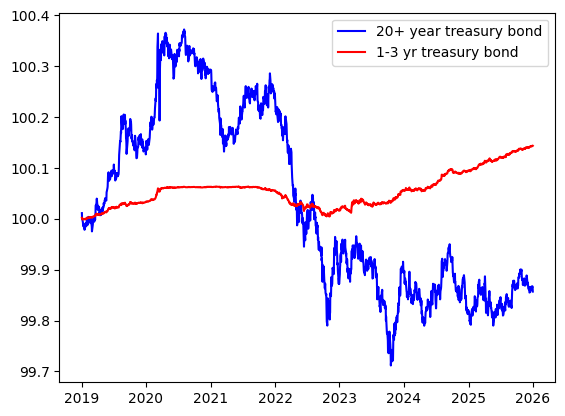

In [190]:
plt.plot(tlt['cumsum_log_ret'], label="20+ year treasury bond", color = "blue")
plt.plot(shy['cumsum_log_ret'], label = "1-3 yr treasury bond", color = "red")
plt.legend()
plt.show()

In [193]:
bond_combined = pd.concat(
    [tlt['log_ret'].rename('tlt'),
     shy['log_ret'].rename('shy'),
     spy['log_ret'].rename('spy')],
     axis = 1
).dropna()

print(f"Aligned observations: {len(bond_combined)}")
bond_corr = bond_combined.corr()


Aligned observations: 1759


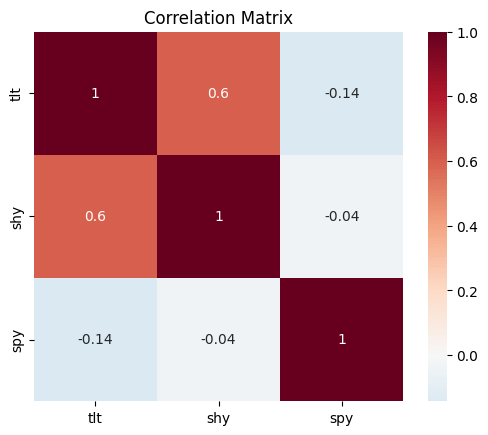

In [194]:
sns.heatmap(
    bond_corr,
    annot=True,
    cmap = 'RdBu_r',
    center=0,
    square=True
)
plt.title('Correlation Matrix')
plt.tight_layout
plt.show()

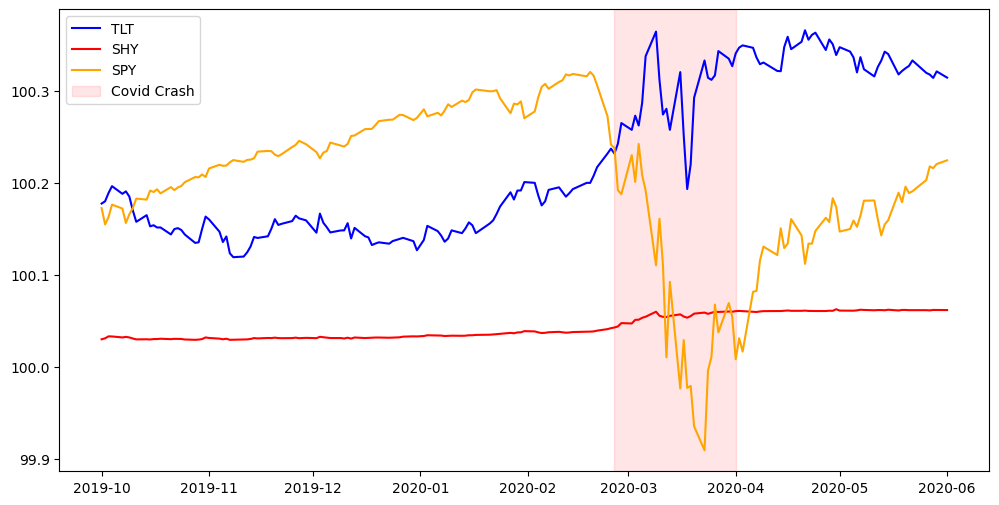

In [199]:
## Visualize

start, end = '2019-10-01', '2020-06-01'
plt.figure(figsize=(12,6))
plt.plot(tlt.loc[start:end, 'cumsum_log_ret'], label = "TLT", color = "blue")
plt.plot(shy.loc[start:end, 'cumsum_log_ret'], label = "SHY", color = "red")
plt.plot(spy.loc[start:end, '100_cum_log_ret'], label="SPY", color="orange")
plt.axvspan(pd.Timestamp('2020-02-26'), pd.Timestamp('2020-04-01'), color="red", alpha=0.1, label = "Covid Crash")
plt.legend(); plt.show()

In [207]:
# Return during market crash
start, end = ('2020-03-01', '2020-04-01')
during_ret = tlt.loc[start:end, 'log_ret'].sum()
during_ret_simple_pct = (np.exp(during_ret) - 1) * 100
print(f"Returns During Market Crash {during_ret_simple_pct}")


start, end = ('2020-03-01', '2020-04-01')
during_corr = tlt.loc[start:end, 'log_ret'].corr(spy.loc[start:end, 'log_ret'])
print(f"Correlation During Market Crash {during_corr:.3f}")

Returns During Market Crash 7.867066728562899
Correlation During Market Crash -0.499


Conclusion: While diversifying across equities can hedge idiosyncratic and industry-specific risk, it cannot hedge market risk. As shown above, when a market crash occurs — as during the COVID era — equities become highly correlated with the market, falling in tandem with it just when diversification is needed most. Bonds behave differently. The 20-year Treasury bond exhibited negative correlation to the market during the crash, gaining value while stocks and the broader market fell. Bonds will not match the long-run returns of equities, but they can serve as a portfolio tool to hedge against market crashes — adding convexity and supporting the ability to rebound from downturns.